In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm

In [2]:
client = scaleout.make_dask_client("tls://localhost:8786")
client

<Client: 'tls://192.168.202.41:8786' processes=14 threads=14, memory=40.42 GiB>

In [3]:
# 01: making sure the notebook runs
# 02: adding more hists and adding all files to more samples in the 2mu and 4mu channel

In [4]:
# Settings
sig_files = -1

vr = "02"

sig_2mu = [
    "2Mu2E_100GeV_5p0GeV_0p4mm",
    "2Mu2E_100GeV_5p0GeV_4p0mm",
    "2Mu2E_100GeV_5p0GeV_40p0mm",
    "2Mu2E_100GeV_5p0GeV_200mm",
    "2Mu2E_100GeV_5p0GeV_400mm",

    "2Mu2E_150GeV_5p0GeV_0p27mm",
    "2Mu2E_150GeV_5p0GeV_2p7mm",
    "2Mu2E_150GeV_5p0GeV_27p0mm",
    "2Mu2E_150GeV_5p0GeV_130p0mm",
    # "2Mu2E_150GeV_5p0GeV_270p0mm",

    "2Mu2E_200GeV_5p0GeV_0p2mm",
    "2Mu2E_200GeV_5p0GeV_2p0mm",
    "2Mu2E_200GeV_5p0GeV_20p0mm",
    "2Mu2E_200GeV_5p0GeV_100p0mm",
    "2Mu2E_200GeV_5p0GeV_200p0mm",
    
    # "2Mu2E_500GeV_5p0GeV_0p08mm",    
    # "2Mu2E_500GeV_5p0GeV_0p8mm",
    # "2Mu2E_500GeV_5p0GeV_8p0mm",
    # "2Mu2E_500GeV_5p0GeV_40p0mm",
    # "2Mu2E_500GeV_5p0GeV_80p0mm",

    # "2Mu2E_800GeV_5p0GeV_0p05mm",
    # "2Mu2E_800GeV_5p0GeV_0p5mm",
    # "2Mu2E_800GeV_5p0GeV_5p0mm",
    # "2Mu2E_800GeV_5p0GeV_25p0mm",
    # "2Mu2E_800GeV_5p0GeV_50p0mm",

    # "2Mu2E_1000GeV_5p0GeV_0p04mm",
    # "2Mu2E_1000GeV_5p0GeV_0p4mm",
    # "2Mu2E_1000GeV_5p0GeV_4p0mm",
    # "2Mu2E_1000GeV_5p0GeV_20p0mm",
    # "2Mu2E_1000GeV_5p0GeV_40p0mm",
    
]

sig_4mu = [
    "4Mu_100GeV_0p25GeV_0p02mm",
    # "4Mu_100GeV_0p25GeV_0p2mm",
    # "4Mu_100GeV_0p25GeV_2p0mm",
    # "4Mu_100GeV_0p25GeV_10p0mm",
    "4Mu_100GeV_0p25GeV_20p0mm",
    
    "4Mu_100GeV_1p2GeV_0p096mm",
    # "4Mu_100GeV_1p2GeV_0p96mm",
    # "4Mu_100GeV_1p2GeV_9p6mm",
    # "4Mu_100GeV_1p2GeV_48p0mm",
    "4Mu_100GeV_1p2GeV_96p0mm",
    
    "4Mu_100GeV_5p0GeV_0p4mm",
    # "4Mu_100GeV_5p0GeV_4p0mm",
    # "4Mu_100GeV_5p0GeV_40p0mm",
    # "4Mu_100GeV_5p0GeV_200mm",
    "4Mu_100GeV_5p0GeV_400mm",
    
    "4Mu_150GeV_0p25GeV_0p013mm",
    # "4Mu_150GeV_0p25GeV_0p13mm",
    # "4Mu_150GeV_0p25GeV_1p3mm",
    # "4Mu_150GeV_0p25GeV_6p7mm",
    "4Mu_150GeV_0p25GeV_13p0mm",
    
    "4Mu_150GeV_1p2GeV_0p064mm",
    # "4Mu_150GeV_1p2GeV_0p64mm",
    # "4Mu_150GeV_1p2GeV_6p4mm",
    # "4Mu_150GeV_1p2GeV_32p0mm",
    "4Mu_150GeV_1p2GeV_64p0mm",
    
    "4Mu_150GeV_5p0GeV_0p27mm",
    # "4Mu_150GeV_5p0GeV_2p7mm",
    # "4Mu_150GeV_5p0GeV_27p0mm",
    # "4Mu_150GeV_5p0GeV_130p0mm",
    "4Mu_150GeV_5p0GeV_270p0mm",
    
    "4Mu_200GeV_0p25GeV_0p01mm",
    # "4Mu_200GeV_0p25GeV_0p1mm",
    # "4Mu_200GeV_0p25GeV_1p0mm",
    # "4Mu_200GeV_0p25GeV_5p0mm",
    "4Mu_200GeV_0p25GeV_10p0mm",
    
    "4Mu_200GeV_1p2GeV_0p048mm",
    # "4Mu_200GeV_1p2GeV_0p48mm",
    # "4Mu_200GeV_1p2GeV_4p8mm",
    # "4Mu_200GeV_1p2GeV_24p0mm",
    "4Mu_200GeV_1p2GeV_48p0mm",
    
    # "4Mu_200GeV_5p0GeV_0p2mm",
    # "4Mu_200GeV_5p0GeV_2p0mm",
    # "4Mu_200GeV_5p0GeV_20p0mm",
    # "4Mu_200GeV_5p0GeV_100p0mm",
    "4Mu_200GeV_5p0GeV_200p0mm",

    "4Mu_500GeV_0p25GeV_0p004mm",
    # "4Mu_500GeV_0p25GeV_0p04mm",
    # "4Mu_500GeV_0p25GeV_0p4mm",
    # "4Mu_500GeV_0p25GeV_2p0mm",
    "4Mu_500GeV_0p25GeV_4p0mm",
    
    "4Mu_500GeV_1p2GeV_0p019mm",
    # "4Mu_500GeV_1p2GeV_0p19mm",
    # "4Mu_500GeV_1p2GeV_1p9mm",
    # "4Mu_500GeV_1p2GeV_9p6mm",
    "4Mu_500GeV_1p2GeV_19p0mm",
    
    "4Mu_500GeV_5p0GeV_0p08mm",
    # "4Mu_500GeV_5p0GeV_0p8mm",
    # "4Mu_500GeV_5p0GeV_8p0mm",
    # "4Mu_500GeV_5p0GeV_40p0mm",
    "4Mu_500GeV_5p0GeV_80p0mm",
    
    "4Mu_800GeV_0p25GeV_0p0025mm",
    # "4Mu_800GeV_0p25GeV_0p025mm",
    # "4Mu_800GeV_0p25GeV_0p25mm",
    # "4Mu_800GeV_0p25GeV_1p2mm",
    "4Mu_800GeV_0p25GeV_2p5mm",
    
    "4Mu_800GeV_1p2GeV_0p012mm",
    # "4Mu_800GeV_1p2GeV_0p12mm",
    # "4Mu_800GeV_1p2GeV_1p2mm",
    # "4Mu_800GeV_1p2GeV_6p0mm",
    "4Mu_800GeV_1p2GeV_12p0mm",
    
    "4Mu_800GeV_5p0GeV_0p05mm",
    # "4Mu_800GeV_5p0GeV_0p5mm",
    # "4Mu_800GeV_5p0GeV_5p0mm",
    # "4Mu_800GeV_5p0GeV_25p0mm",
    "4Mu_800GeV_5p0GeV_50p0mm",
    
    "4Mu_1000GeV_0p25GeV_0p002mm",
    # "4Mu_1000GeV_0p25GeV_0p02mm",
    # "4Mu_1000GeV_0p25GeV_0p2mm",
    # "4Mu_1000GeV_0p25GeV_1p0mm",
    "4Mu_1000GeV_0p25GeV_2p0mm",
    
    "4Mu_1000GeV_1p2GeV_0p0096mm",
    "4Mu_1000GeV_1p2GeV_0p096mm",
    "4Mu_1000GeV_1p2GeV_0p96mm",
    "4Mu_1000GeV_1p2GeV_4p8mm",
    "4Mu_1000GeV_1p2GeV_9p6mm",
    
    "4Mu_1000GeV_5p0GeV_0p04mm",
    "4Mu_1000GeV_5p0GeV_0p4mm",
    "4Mu_1000GeV_5p0GeV_4p0mm",
    "4Mu_1000GeV_5p0GeV_20p0mm",
    "4Mu_1000GeV_5p0GeV_40p0mm",
]

channels = ["baseNoLj"] #sel.yaml

allsamples = sig_2mu + sig_4mu

ch1 = channels[0]
# ch2 = channels[1]

In [5]:
# processor 
runner = processor.Runner(
    # executor=processor.FuturesExecutor(),
    # executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema = llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(
    channels,
    ["gen_base", "electron_base", "muon_base", "photon_base", "dsaMuon_base"], #hist coleection
)

# for 2mu2e
fileset_sig_2mu = utilities.make_fileset(sig_2mu, "llpNanoAOD_v2", max_files=sig_files, location_cfg="signal_2mu2e_v10.yaml")
out_sig2 = runner.run(fileset_sig_2mu, treename="Events", processor_instance=p)
out_sig2 = out_sig2["out"]

# processor for 4mu
fileset_sig_4mu = utilities.make_fileset(sig_4mu,  "llpNanoAOD_v2", max_files = sig_files, location_cfg = "signal_4mu_v10.yaml")
out_sig4 = runner.run(fileset_sig_4mu, treename="Events", processor_instance=p)
out_sig4 = out_sig4["out"]


Output()

Output()

2Mu2E_200GeV_5p0GeV_200p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_200GeV_5p0GeV_0p2mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_150GeV_5p0GeV_130p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_200GeV_5p0GeV_2p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_200GeV_5p0GeV_20p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_200GeV_5p0GeV_100p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_100GeV_5p0GeV_0p4mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_100GeV_5p0GeV_4p0mm is simulation. Scaling histograms or cutflows according to lumi*

Output()

Output()

4Mu_1000GeV_5p0GeV_40p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_1000GeV_5p0GeV_0p4mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_1000GeV_5p0GeV_4p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_1000GeV_5p0GeV_20p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_150GeV_0p25GeV_13p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_100GeV_0p25GeV_0p02mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_100GeV_0p25GeV_20p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_100GeV_1p2GeV_0p096mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signa

In [6]:
out_all = out_sig2 | out_sig4
coffea.util.save(out_all, "outputs/master_" + vr + ".coffea")

## Start plotting

In [7]:
# opening file
output = coffea.util.load("outputs/master_" + vr + ".coffea")
out = output

### Gen quantities

In [24]:
figw, figh, npl = 12, 10, 2


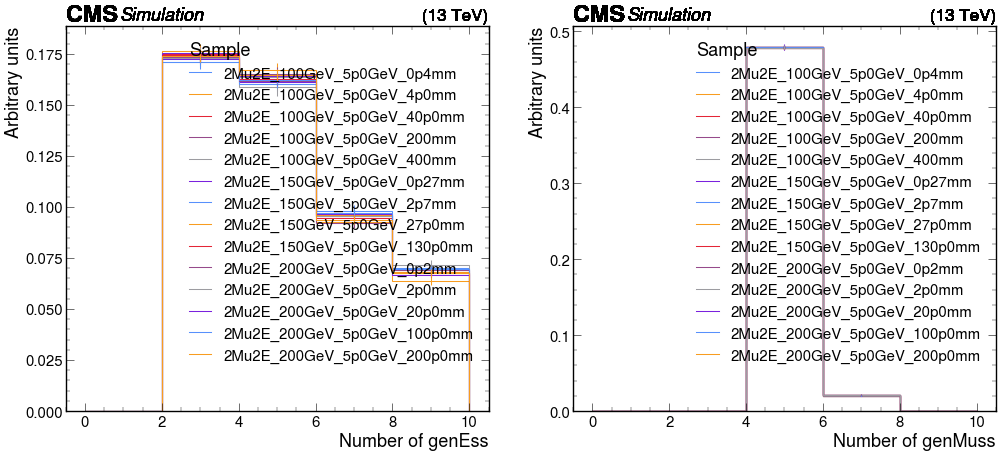

In [25]:
# n
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE_n"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu_n"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
# plt.savefig(f"plots/master_{vr}_n", bbox_inches="tight")

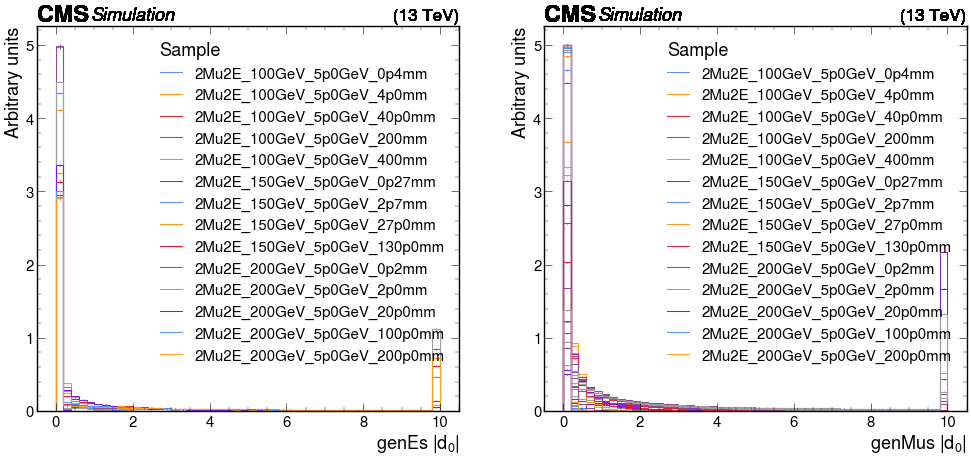

In [26]:
# dxy
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE_dxy"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu_dxy"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
# plt.savefig(f"plots/master_{vr}_dxy", bbox_inches="tight")

In [11]:
# eta_phi
# plt.subplots(1, npl, figsize=(npl*figw, figh))
# plt.subplot(1, npl, 1)
# for sss in sig_2mu:
#     utilities.plot(out[sss]["hists"]["genE_eta_phi"][ch1, :, :].project("genE_eta"), )
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 2)
# for sss in sig_4mu:
#     utilities.plot(out[sss]["hists"]["muon_eta_phi"][ch1, :, :].project("muons_eta"), )
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sss in sig_4mu:
#     utilities.plot(out[sss]["hists"]["dsaMuon_n"][ch1, ::2j], label = sig_4mu, density=True)
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")

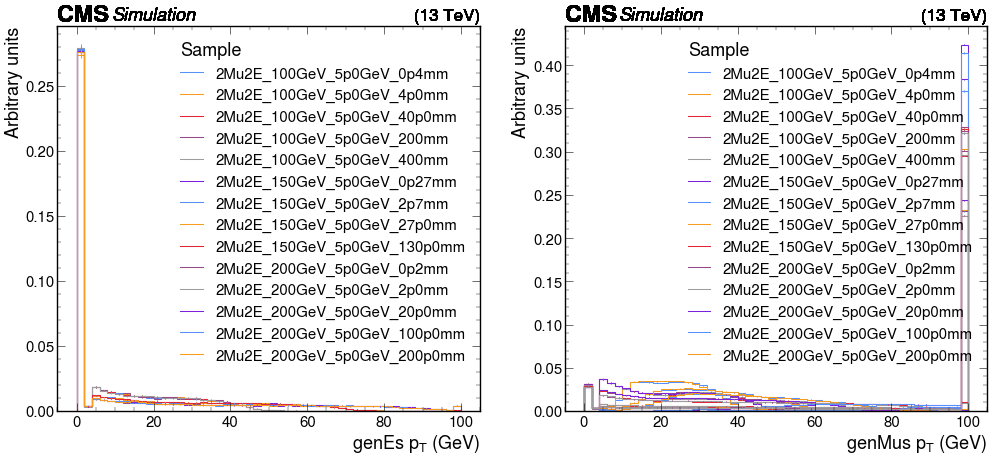

In [27]:
# pt
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
# plt.savefig(f"plots/master_{vr}_pt", bbox_inches="tight")

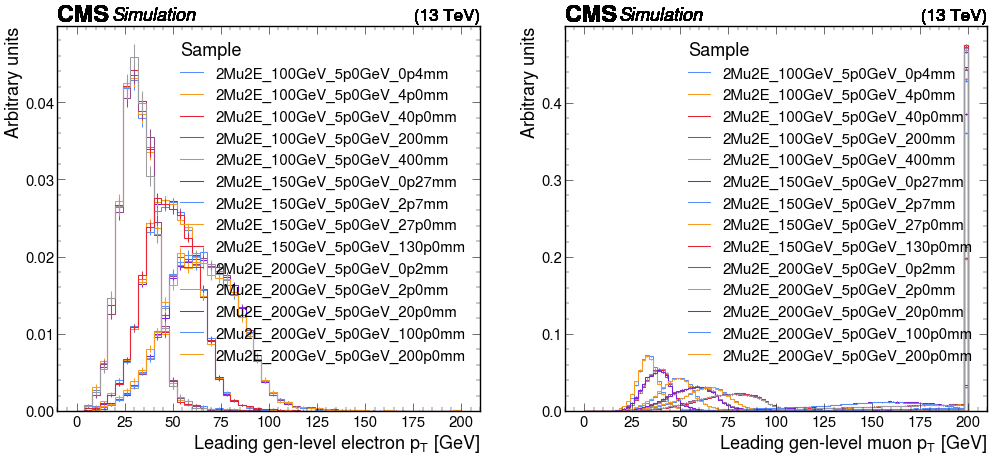

In [28]:
# leading pt
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE0_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu0_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")
# plt.savefig(f"plots/master_{vr}_Lead_pt", bbox_inches="tight")

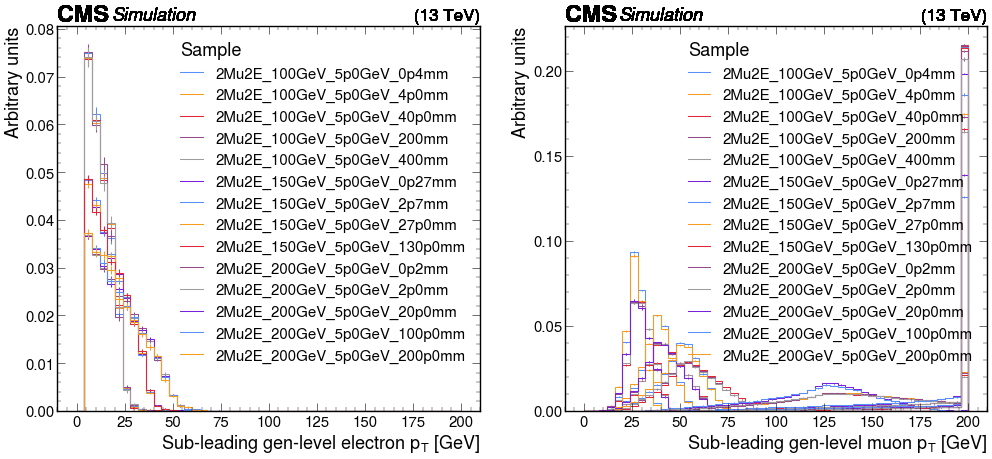

In [29]:
# sleading pt
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE1_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu1_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/master_{vr}_sLead_pt", bbox_inches="tight")

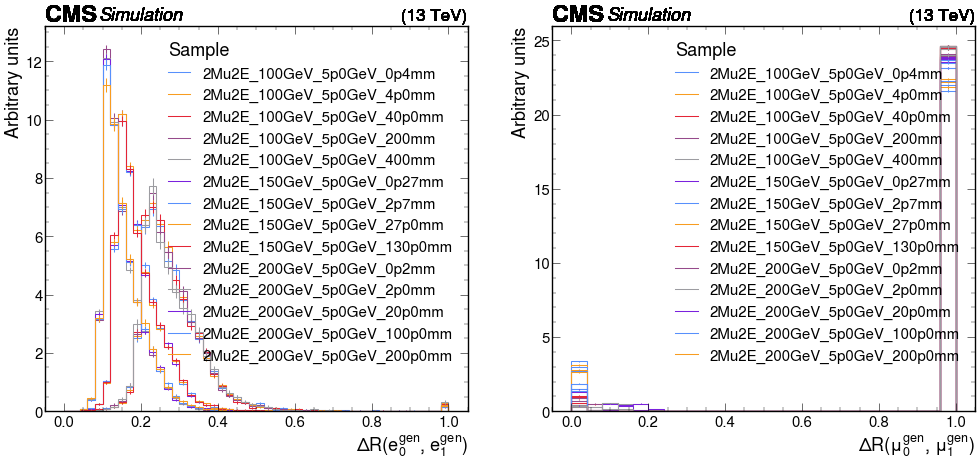

In [30]:
# dR
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["genE_genE_dR"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["genMu_genMu_dR"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/master_{vr}_dR", bbox_inches="tight")

## Reco quantities

In [31]:
figw, figh, npl = 12, 10, 3

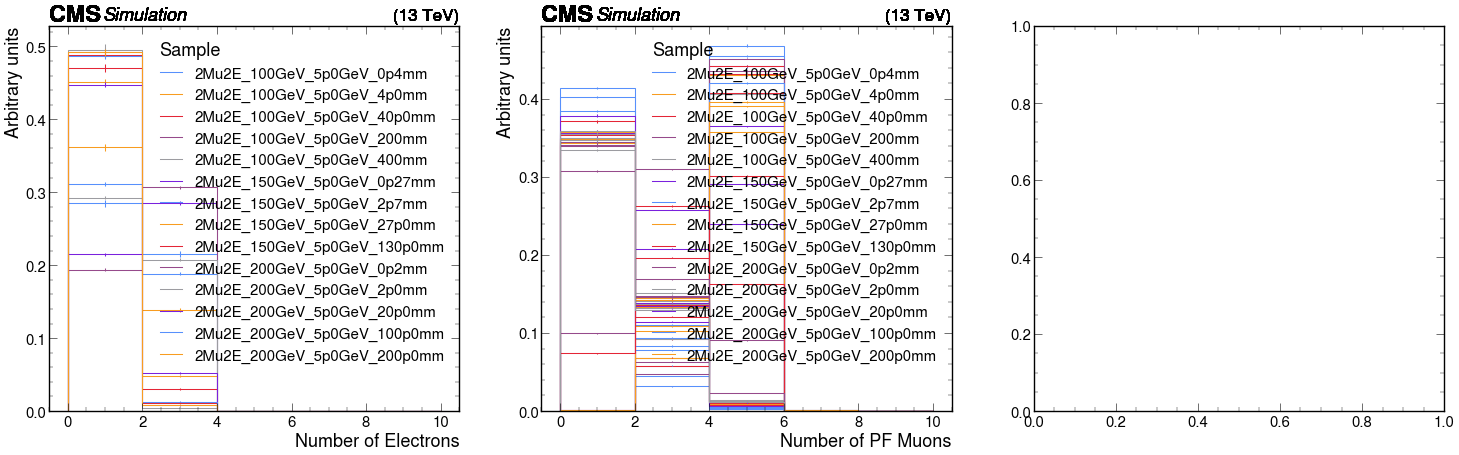

In [32]:
# n
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["electron_n"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["muon_n"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sss in sig_4mu:
#     utilities.plot(out[sss]["hists"]["dsaMuon_n"][ch1, ::2j], label = sig_4mu, density=True)
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/master_{vr}_n", bbox_inches="tight")

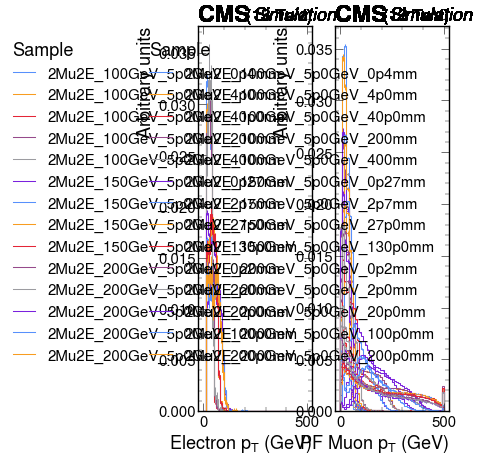

In [18]:
# pt
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["electron_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["muon_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sss in sig_4mu:
#     utilities.plot(out[sss]["hists"]["dsaMuon_n"][ch1, ::2j], label = sig_4mu, density=True)
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")
    
# plt.savefig(f"plots/master_{vr}_pt", bbox_inches="tight")

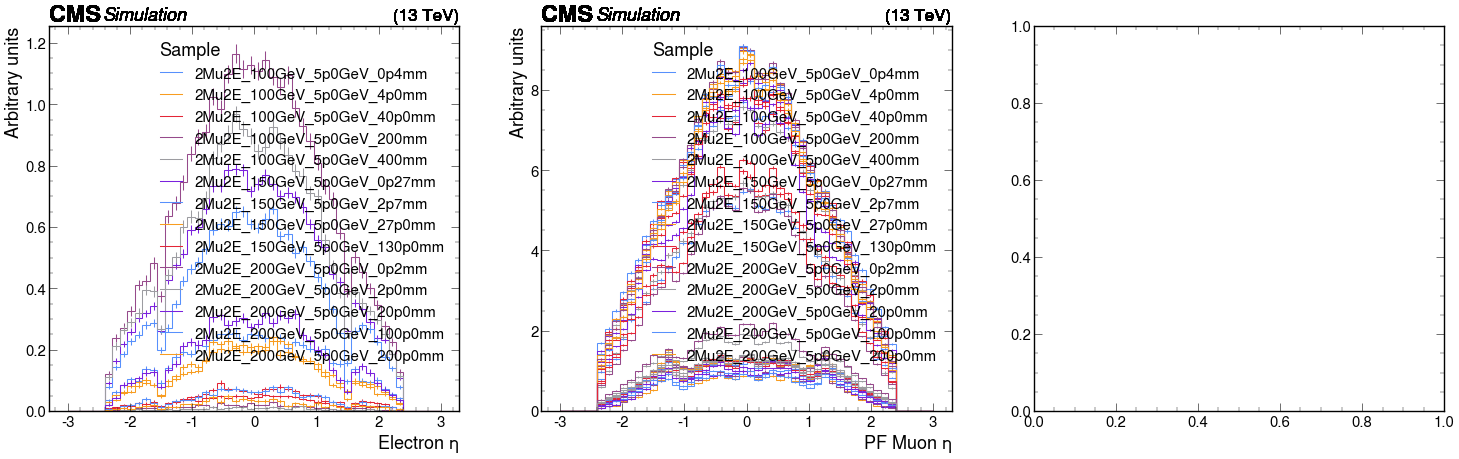

In [19]:
# eta_phi
plt.subplots(1, npl, figsize=(npl*figw, figh))
plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["electron_eta_phi"][ch1, :, :].project("electrons_eta"), )
    # utilities.plot(out[sss]["hists"]["electron_eta_phi"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["muon_eta_phi"][ch1, :, :].project("muons_eta"), )
    # utilities.plot(out[sss]["hists"]["muon_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
    plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sss in sig_4mu:
#     utilities.plot(out[sss]["hists"]["dsaMuon_n"][ch1, ::2j], label = sig_4mu, density=True)
#     plt.legend(sig_2mu, title="Sample", alignment="left", loc="upper right")
#     plt.ylabel("Arbitrary units")

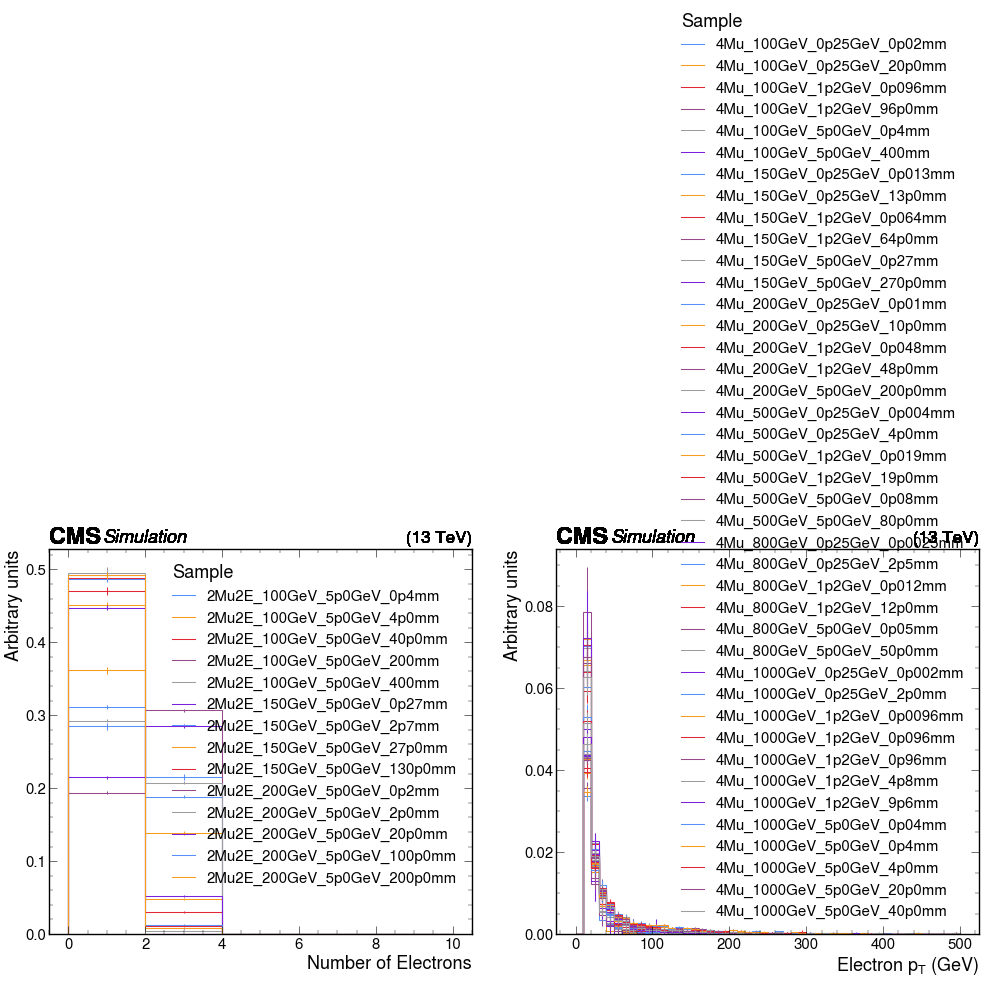

In [20]:


npl = 2
plt.subplots(1, npl, figsize=(npl*figw, figh))

plt.subplot(1, npl, 1)
for sss in sig_2mu:
    utilities.plot(out[sss]["hists"]["electron_n"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(sig_2mu, title="Sample", alignment="left", loc=0)
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in sig_4mu:
    utilities.plot(out[sss]["hists"]["electron_pt"][ch1, ::2j], label = sig_4mu, density=True)
    plt.legend(sig_4mu, title="Sample", alignment="left", loc=0)
    plt.ylabel("Arbitrary units")

In [21]:
raise SystemExit("Notebook stopped intentionally after this cell.")

SystemExit: Notebook stopped intentionally after this cell.

/usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:

npl = 2
plt.subplots(1, npl, figsize=(npl*figw, figh))
print(allsamples)
plt.subplot(1, npl, 1)
for sss in allsamples:
    # print(sss)
    utilities.plot(out[sss]["hists"]["electron_n"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in allsamples:
    utilities.plot(out[sss]["hists"]["electron_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

# plt.subplot(1, npl, 3)
# for sss in allsamples[1:]:
#     utilities.plot(out[sss]["hists"]["lj_pt"][ch3, ::2j], label = sig_2mu, density=True)
#     plt.legend(allsamples, title="Sample", alignment="left", loc=0)
#     # plt.title("den")
#     plt.ylabel("Arbitrary units")

# plt.savefig(f"plots/BKG_{vr}_lj_pt", bbox_inches="tight")

In [ ]:
#pf dsa muons at mxx=100
for mu in ["pf", "dsa"]:
    fig, ax = plt.subplots(1, 3, figsize=(3*figw, figh))
    
    for fi, cl, lbl in zip(vr, cols, labels):    
        output = coffea.util.load("outputs/Eff_" + vr + ".coffea")
        out = output["out"]
        
        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[0].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[0].set_ylabel("Efficiency")
    ax[0].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[0].set_title(f"{mu} muons (L)")
    ax[0].set_ylim(0, 1.10)
    ax[0].legend(title=r"$\Delta R >$ ", loc=0)
    ax[0].grid(True, linestyle="--", alpha=0.6)
    
    #subleading muon
    for fi, cl, lbl in zip(vr, cols, labels):    
        output = coffea.util.load("outputs/Eff_" + vr + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[1].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[1].set_ylabel("Efficiency")
    ax[1].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[1].set_title(f"{mu} muons (S)")
    ax[1].set_ylim(0, 1.10)
    ax[1].legend(title=r"$\Delta R >$ ", loc=0)
    ax[1].grid(True, linestyle="--", alpha=0.6)

    #leading + subleading muon
    for fi, cl, lbl in zip(vr, cols, labels):    
        output = coffea.util.load("outputs/Eff_" + vr + ".coffea")
        out = output["out"]

        num, den = 0, 0
        for sss in allSamples[:5]:
            num = num + out[sss]["hists"]["num_genAs_toMu0_lxy_" + mu][ch2, ::2j] + out[sss]["hists"]["num_genAs_toMu1_lxy_" + mu][ch2, ::2j]
            den = den + out[sss]["hists"]["den_genAs_toMu0_lxy"][ch2, ::2j] + out[sss]["hists"]["den_genAs_toMu1_lxy"][ch2, ::2j]
        
        eff, errors = utilities.get_eff_hist(num, den)
        centers = num.axes[0].centers
        ax[2].errorbar(centers, eff, yerr=errors, fmt="o", color=cl, label=lbl, capsize=2)
    
    ax[2].set_ylabel("Efficiency")
    ax[2].set_xlabel("genAs $L_{xy}$ [cm]")
    ax[2].set_title(f"{mu} muons (L+S)")
    ax[2].set_ylim(0, 1.10)
    ax[2].legend(title=r"$\Delta R >$ ", loc=0)
    ax[2].grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    # plt.savefig(f"plots/eff_35_{mu}_genA_lxy_m100.png", bbox_inches="tight")

In [ ]:
# My parameters
vr = "05"
numfiles = 10

#samples

sig_2mu = [
    "2Mu2E_100GeV_5p0GeV_0p4mm",
    # "2Mu2E_150GeV_5p0GeV_0p27mm",
    # "2Mu2E_200GeV_5p0GeV_0p2mm",
    "2Mu2E_500GeV_5p0GeV_0p08mm",
    # "2Mu2E_500GeV_5p0GeV_80p0mm",
    # "2Mu2E_800GeV_5p0GeV_0p05mm",
    # "2Mu2E_1000GeV_5p0GeV_0p04mm",
]

sig_4mu = [
    "4Mu_100GeV_5p0GeV_0p4mm",
    # "4Mu_150GeV_5p0GeV_0p27mm",
    # "4Mu_200GeV_5p0GeV_0p2mm",
    "4Mu_500GeV_5p0GeV_0p08mm",
    # "4Mu_500GeV_5p0GeV_80p0mm",
    # "4Mu_800GeV_5p0GeV_0p05mm",
    # "4Mu_1000GeV_5p0GeV_0p04mm",
]

bkg = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
    "TTJets",
    # "QCD_Pt15To20",
    # "QCD_Pt20To30",
    # "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    # "QCD_Pt120To170",
    # "QCD_Pt170To300",
    # "QCD_Pt300To470",
    # "QCD_Pt470To600",
    # "QCD_Pt600To800",
    # "QCD_Pt800To1000",
    # "QCD_Pt1000",       
]

sig_2mu + sig_4mu + bkg
